In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

df=pd.read_csv('ab-test.csv')

In [60]:
df.loc[df["group"]=="test"].head()

,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test


In [61]:
df.loc[df["group"]=="control"].head()

,uid,diff,time,group
14,user_12,-75.0,after,control
15,user_12,-103.0,before,control
16,user_13,-81.5,after,control
17,user_13,-15.5,before,control
18,user_15,-32.0,after,control


In [62]:
df_before = df.loc[df['time'] == 'before']
df_after = df.loc[df['time'] == 'after']

In [63]:
data_before=[df_before[df_before['group'] == 'control']['diff'],df_before[df_before['group'] == 'test']['diff']]
data_after=[df_after[df_after['group'] == 'control']['diff'],df_after[df_after['group'] == 'test']['diff']]

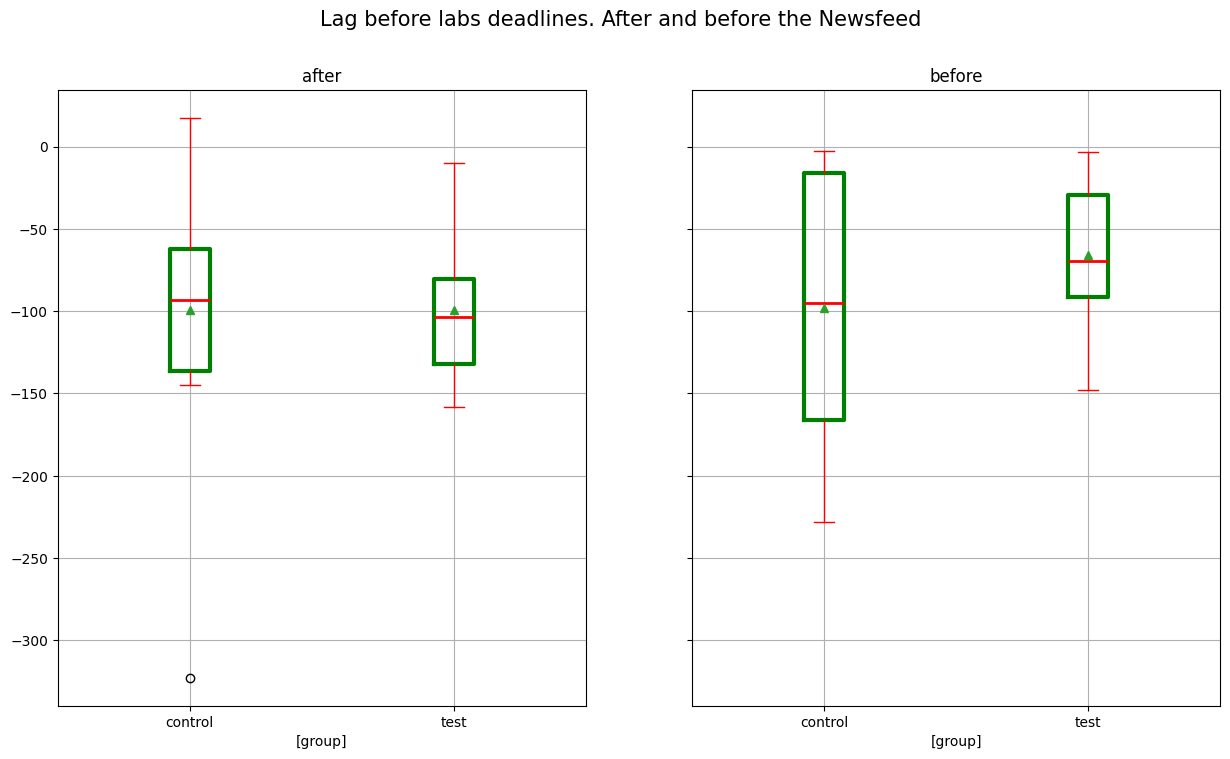

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=True)
fig.suptitle('Lag before labs deadlines. After and before the Newsfeed', fontsize=15)

axes[0].boxplot(data_after, showmeans=True, 
                meanprops=dict(color='green'), 
                boxprops=dict(color='green', linewidth=3), medianprops=dict(color='red', linewidth=2), 
                flierprops=dict(marker='o', color='black'), 
                whiskerprops=dict(color='red'), capprops=dict(color='red'))
axes[0].set_title('after')
axes[0].set_xlabel('[group]')
axes[0].set_xticklabels(['control', 'test'])
axes[0].grid(True)

axes[1].boxplot(data_before, showmeans=True, 
                meanprops=dict(color='green'), 
                boxprops=dict(color='green', linewidth=3), medianprops=dict(color='red', linewidth=2), 
                flierprops=dict(marker='o', color='black'), 
                whiskerprops=dict(color='red'), capprops=dict(color='red'))
axes[1].set_title('before')
axes[1].set_xlabel('[group]')
axes[1].set_xticklabels(['control', 'test'])
axes[1].grid(True)


Приблизительно от -20 до -170. Значит межквартильный размах контрольной группы до добавления новостной ленты был 150

In [67]:
q1 = data_before[0].quantile(0.25)
q3 = data_before[0].quantile(0.75)
iqr = q3 - q1
iqr

np.float64(150.0)